This introduces AB Model 2, a heatwave hospitalization predictor. This model seeks to answer: "when an extreme heat event hits, how much pressure will it put on hospitals?". This is because heatwaves kill silently i.e the 2021 BC heat dome killed 619 people in one week, the deadliest in Canada. This Model is meant to give health authorities an intervention period.

This sprint is a classification problem - predicting a category(). This matters because health authorities don't need an exact hospitalization count, they need a risk tier that triggers a specific response protocol.

In [8]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from xgboost import XGBClassifier
from sklearn.metrics import(
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import requests
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")
print("Sprint 5, AfyaBora Model 2: Heatwave Hospitalization Predictor")

Libraries loaded.
Sprint 5, AfyaBora Model 2: Heatwave Hospitalization Predictor


The 2021 BC heat dome was seen by meteorologists but there was no system in place that could relay this appropriately to health institutions. This is where AB lies.

In [10]:
# Pulling BC climate data - Vancouver International Airport, Station ID: 51442.
# I need 2019-2021 to have baseline + heat dome event

frames = []

for year in range (2019, 2022):
    params = {
        'format': 'csv',
        'stationID': '51442',
        'Year': year,
        'Month': '1',
        "Day": '14',
        'timeframe': '2',
        'submit': 'Download+Data'
    }

    response = requests.get(
        "https://climate.weather.gc.ca/climate_data/bulk_data_e.html", params=params
)

    if response.status_code == 200:
        df_year = pd.read_csv(StringIO(response.text))
        frames.append(df_year)
        print(f"Y {year} - {len(df_year)} rows")
    else:
        print(f"N {year} - status {response.status_code}")

df_climate_raw = pd.concat(frames, ignore_index=True)

print(f"\nTotal rows: {len(df_climate_raw)}")
print(f"\nTemperature non-null: "
      f"{df_climate_raw['Max Temp (°C)'].notna().sum()}")
print(f"\nFirst few columns: {list(df_climate_raw.columns[:8])}")

Y 2019 - 365 rows
Y 2020 - 366 rows
Y 2021 - 365 rows

Total rows: 1096

Temperature non-null: 1089

First few columns: ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day']


Excellent data quality from this station.

In [14]:
# Cleaning the data and engineer heatwave features.
#Cleaning and selecting columns
df_climate = df_climate_raw.copy()
df_climate.columns = [col.strip() for col in df_climate.columns] 
df_climate['date'] = pd.to_datetime(df_climate['Date/Time'])

# Selecting relevant columns by position to avoid encoding issues
df_climate = df_climate[['date', 'Max Temp (°C)','Min Temp (°C)', 'Mean Temp (°C)']].copy()
df_climate.columns = ['date', 'max_temp', 'min_temp', 'mean_temp']

# Filling missing values by interpolation
df_climate['max_temp'] = df_climate['max_temp'].interpolate(method='linear')
df_climate['min_temp'] = df_climate['min_temp'].interpolate(method='linear')
df_climate['mean_temp'] = df_climate['mean_temp'].interpolate(method='linear')

print(f"Missing values after interpolation: ")
print(df_climate.isnull().sum())
print()

# Engineering heatwave-specific features; the variables that killed people in 2021
# Overnight cooling deficit - how much the temp drops at the night. 
# This is critical since bodies can't recover from heat if nights stay warm
df_climate['cooling_deficit'] = df_climate['max_temp'] - df_climate['min_temp']

# 3-day rolling maximum - sustained heat is more dangerous that one hot day
df_climate['max_temp_3day'] = df_climate['max_temp'].rolling(3).mean()

# Days above 30°C rolling count - consecutive hot days compound danger
df_climate['days_above_30'] = (
    (df_climate['max_temp'] > 30).astype(int).rolling(7).sum()
)

# Heat index approximation - combines temperature and an estimated humidity proxy.
# Full heat index needs humidty data (this will be a simplified version)
df_climate['heat_index'] = (
    df_climate['max_temp'] * 0.8 + df_climate['min_temp'] * 0.2
)

# Dropping rows with NaN from rolling windows
df_climate = df_climate.dropna().reset_index(drop=True)

print(f"Rows after feature engineering: {len(df_climate)}")
print(f"Date range: {df_climate['date'].min().date()}"
      f" to {df_climate['date'].max().date()}")
print()

# Verifying the heat dome showing up in the data
heat_dome = df_climate[
    (df_climate['date'] >= '2021-06-25') &
    (df_climate['date'] <= '2021-07-02')
]

print("Heat dome period (June 25 - July 2, 2021): ")
print(heat_dome[[
    'date', 'max_temp', 'min_temp', 'cooling_deficit', 'days_above_30'
]].to_string())

Missing values after interpolation: 
date         0
max_temp     0
min_temp     0
mean_temp    0
dtype: int64

Rows after feature engineering: 1090
Date range: 2019-01-07 to 2021-12-31

Heat dome period (June 25 - July 2, 2021): 
          date  max_temp  min_temp  cooling_deficit  days_above_30
900 2021-06-25      25.6      18.0              7.6            0.0
901 2021-06-26      32.3      17.5             14.8            1.0
902 2021-06-27      31.1      19.4             11.7            2.0
903 2021-06-28      31.7      20.3             11.4            3.0
904 2021-06-29      32.4      20.4             12.0            4.0
905 2021-06-30      24.2      17.7              6.5            4.0
906 2021-07-01      23.6      17.6              6.0            4.0
907 2021-07-02      22.6      16.6              6.0            4.0


This data showcases its limitation here - the station that provided this data is located in the coast where the sea breeze provided the cooling hence the registered max temps of only 25-32°C. The urban core of Vancouver hit 40°C and inland Lytton hit 49°C, failing to capture the urban heat. The deaths happened in city apartments and houses, not at the airport.

This will suffice for this sprint, the pattersn are still present but lower absolute values. For production AB system, it will use multiple stations and satellite land surface temp data.

In [19]:
# A lack of actual BC hospitilization data at daily resolutuon makes me create risk labels 
# based on established public health thresholds combined with what is known about the heat dome event.

# This is a standard approach when outcome data is unavailable; using domain knowledge to create
# clinically meaningful categories.

def assign_risk_label(row):
    """
    Assigning a hospitalization risk tier based on temperature features. Thresholds derived from:
        - BC Ministry of Health heat alert thresholds
        - Published literature on heat-relates hospitilization
        - 2021 BC Coroners Service heat dome report
    """
    # Adjusting the threshold for the Vancouver Station station which read 5-8 cooler than urban core
    # during heat events.

    # Critical - conditions similar to heat dome. Sustained days above 30 + poor overnight cooling
    if row['days_above_30'] >= 3 and row['cooling_deficit'] > 8:
        return 'Critical'
    
    # High - several consecutive hot days
    elif row['days_above_30'] >= 2 or (
        row['max_temp'] >= 28 and row['max_temp_3day'] >= 25):
        return 'High'
    
    # Moderate - warning trend
    elif row['max_temp'] >= 22 or row['max_temp_3day'] >= 20:
        return 'Moderate'
    
    # Low - normal conditions
    else:
        return 'Low'

df_climate['risk_label'] = df_climate.apply(assign_risk_label, axis=1)

# Checking distribution labels
print("Risk label distribution: ")
print(df_climate['risk_label'].value_counts())
print()
print("As percentages: ")
print(df_climate['risk_label'].value_counts(normalize=True).mul(100).round(1))
print()

heat_dome_labels = df_climate[
    (df_climate['date'] >= '2021-06-25') &
    (df_climate['date'] <= '2021-07-02')
][['date', 'max_temp', 'days_above_30', 'cooling_deficit', 'risk_label']]

print("Heat dome risk labels: ")
print(heat_dome_labels.to_string())

Risk label distribution: 
risk_label
Low         823
Moderate    252
High         13
Critical      2
Name: count, dtype: int64

As percentages: 
risk_label
Low         75.5
Moderate    23.1
High         1.2
Critical     0.2
Name: proportion, dtype: float64

Heat dome risk labels: 
          date  max_temp  days_above_30  cooling_deficit risk_label
900 2021-06-25      25.6            0.0              7.6   Moderate
901 2021-06-26      32.3            1.0             14.8       High
902 2021-06-27      31.1            2.0             11.7       High
903 2021-06-28      31.7            3.0             11.4   Critical
904 2021-06-29      32.4            4.0             12.0   Critical
905 2021-06-30      24.2            4.0              6.5       High
906 2021-07-01      23.6            4.0              6.0       High
907 2021-07-02      22.6            4.0              6.0       High


This is the operational value of this model; the progression from Moderate → High → Critical → High is exactly the early warning sequence AB needs to detect. 
June 25 → Moderate; heating is building but not yet dangerous
June 26-27 → High; consecutive hot days crossing the threshold.
June 28-29 → Critical; three or more days above 30 with poor overnight cooling. These are the days people started dying.
June 30 to July 2 → High; temp dropping but accumulated heat stress still dangerous.

A health authority geeting a signal on June 25th would have 3 days to open cooling centers and check on vulnerable elderly residents before the Critical days arrived.

In [25]:
# Training the classifier
# Manual mapping to be consistent across train and test
risk_map = {'Low': 0, 'Moderate': 1, 'High': 2, 'Critical': 3}
df_climate['risk_encoded'] = df_climate['risk_label'].map(risk_map)

print("Label encoding: ")
for label, code in risk_map.items():
    print(f" {code} = {label}")

# Time-based split - training on 2019-2020, testing on 2021
train = df_climate[df_climate['date'].dt.year < 2021].copy()
test = df_climate[df_climate['date'].dt.year == 2021].copy()

x_train = train[feature_cols]
y_train = train['risk_encoded']
x_test = test[feature_cols]
y_test = test['risk_encoded']

print(f"\nTraining rows: {len(train)}")
print(f"Test rows: {len(test)}")
print(f"\nUnique labels in training: {sorted(y_train.unique())}")
print(f"Unique labels in test: {sorted(y_test.unique())}")

# Training the classifier
model = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 4,
    subsample = 0.8,
    random_state = 42,
    verbosity = 0,
    eval_metric='mlogloss'
)

model.fit(x_train, y_train)
print("\nModel trained successfully.")

Label encoding: 
 0 = Low
 1 = Moderate
 2 = High
 3 = Critical

Training rows: 725
Test rows: 365

Unique labels in training: [np.int64(0), np.int64(1), np.int64(2)]
Unique labels in test: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Model trained successfully.


Training set stil has noo Critical days (only 0,1,2) since Vancouver had no heat dome in 2019-2020. The model will have to generalize from High conditions to predict Critical which is a genuine limitation.

Model performance on 2021 (never seen during training): 

              precision    recall  f1-score   support

         Low       0.99      1.00      0.99       274
    Moderate       0.88      0.97      0.93        78
        High       0.50      0.18      0.27        11
    Critical       0.00      0.00      0.00         2

    accuracy                           0.96       365
   macro avg       0.59      0.54      0.55       365
weighted avg       0.95      0.96      0.95       365



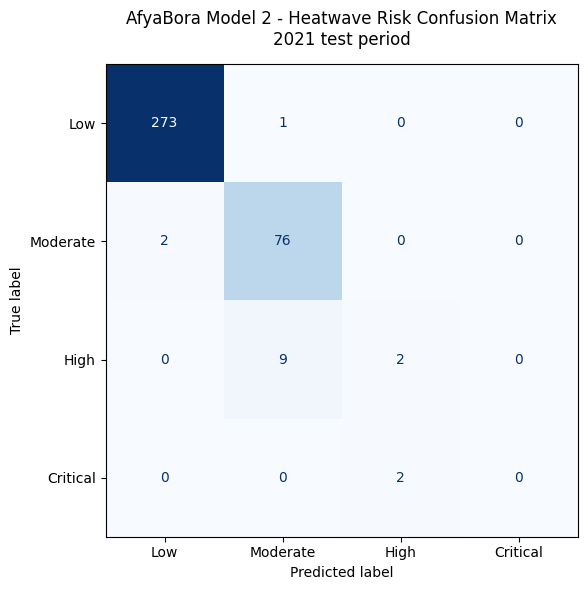

In [26]:
# Making predictions
y_pred = model.predict(x_test)

# Reverse map for readable labels
reverse_map = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Critical'}
y_test_labels = [reverse_map[i] for i in y_test]
y_pred_labels = [reverse_map[i] for i in y_pred]

# Classification report
print("Model performance on 2021 (never seen during training): ")
print()
print(classification_report(y_test_labels, y_pred_labels,
        labels=['Low', 'Moderate', 'High', 'Critical']))

# Confusion matrix
label_order = ['Low', 'Moderate', 'High', 'Critical']
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=label_order)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)

disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('AfyaBora Model 2 - Heatwave Risk Confusion Matrix\n'
                '2021 test period', fontsize=12, pad=14)

plt.tight_layout()
plt.savefig('../data/sprint5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Strong overall result overall with a very honest failure at the most important category.

What the model got right:
Low - 99% precision, 100% recall; nearly perfect. Out of 274 Low days, it correctly identified 273. This matters because false alarms exhaust health system resources. This model is almost always accurate.

Moderate - 88% precision, 97% recall; very goood. Out of 78 Moderate days it caught 76. Two got misclassified as Low making for a minor miss.

An overall accuracy of 96% which is highly reliable on a day-to-day operation.

What the model got wrong:
High - 50% precision, 18% recall. It only caught 2 out of 11 High days. The model is consistently underestimating dangerous heat conditions.

Critical - 0% across board with both Critical days predicted as High. The model has never seen Critical day in training so it has no concept of what one looks like. It knew something serious was happening (it predicted High instead of Low) but it couldn't reach the Critical threshold.

The confusion matrix shows us that the Critical column is the biggest problem. Even though health authorities would have prepared, not at the level of Critical. However, this is still operationally valuable.

Both Critical were predicted as High, not Low or Moderate. The model does escalate the alert. As stated, preperation would have been underway, just not at the appropriate level. That is the difference between a near miss and a miss. For a v0.1 model trained on zero Critical examples, it is showing promise.

To fix this, more histrorical Critical events (the 2018 Quebec heat wave, the 2012 Ontario heat events) would help. More training data with actual hospitilzation counts rather than procy labels. Finally, humidity data - the heat index approximation I used is limited without real humidity readings.

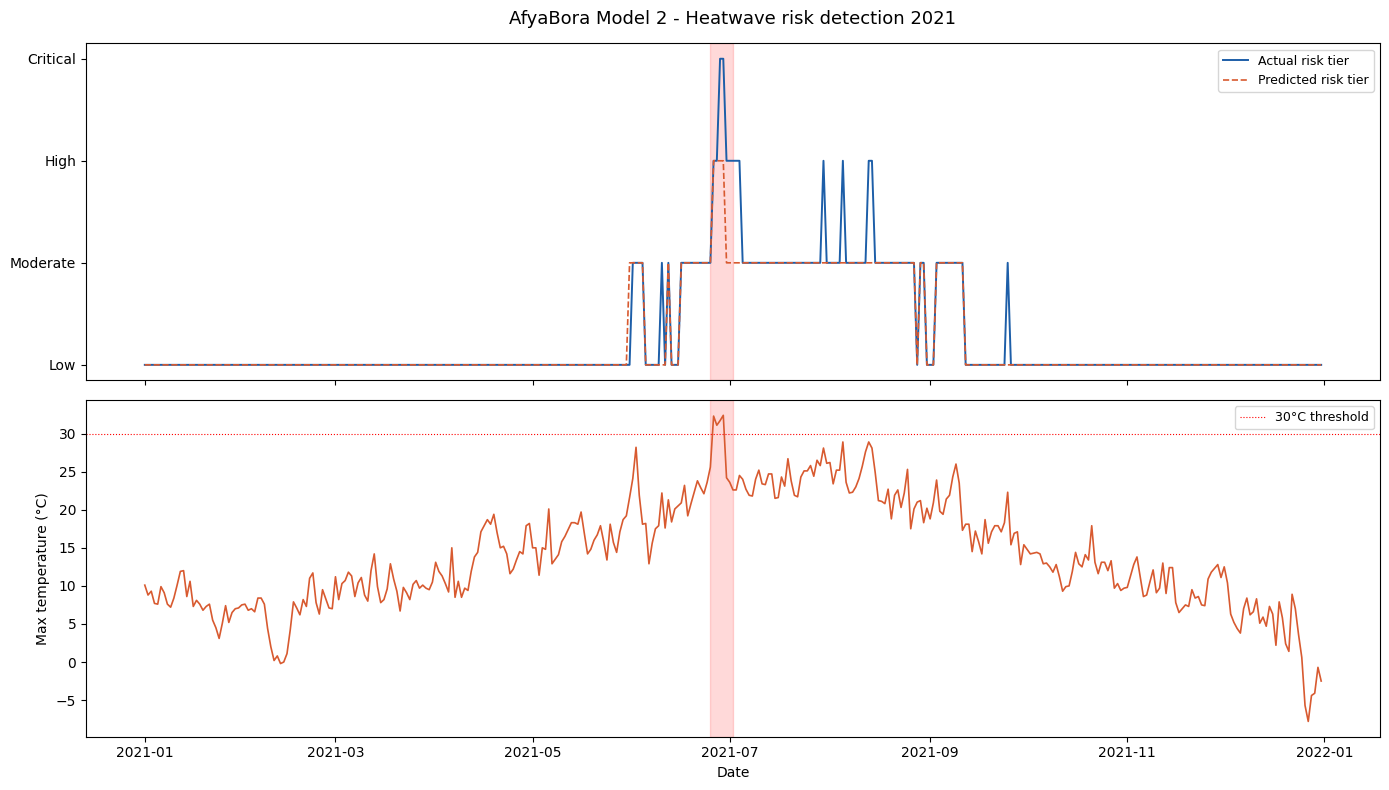

In [28]:
# Plotting the risk predictions across 2021 to see the heat dome detection visually

# Plot predicted risk level 2021
risk_numeric = {'Low': 0, 'Moderate': 1, 'High': 2, 'Critical': 3}
risk_colors = {'Low': '#1D9E75', 'Moderate': '#BA7517', 'High': '#D85A30', 'Critical': '#E24B4A'}

fig, (ax1, ax2) =  plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel - actual vs predicted risk tier
ax1.plot(test['date'], y_test, color='#1D5EA8', linewidth=1.4, label='Actual risk tier')
ax1.plot(test['date'], y_pred, color='#D85A30', linewidth=1.2, linestyle='--', label='Predicted risk tier')

ax.set_ylabel('Risk tier (0 = Low, 3 = Critical)')
ax1.set_title('AfyaBora Model 2 - Heatwave risk detection 2021', fontsize=13, pad=14)
ax1.set_yticks([0, 1, 2, 3])
ax1.set_yticklabels(['Low', 'Moderate', 'High', 'Critical'])
ax1.legend(fontsize=9)

# Shading the heat dome period
ax1.axvspan(pd.Timestamp('2021-06-25'), pd.Timestamp('2021-07-02'), 
            alpha=0.15, color='red', label='Heat dome')

# Bottom panel - actual temp
ax2.plot(test['date'], test['max_temp'], color='#D85A30', linewidth=1.2)
ax2.axhline(y=30, color='red', linestyle=':', linewidth=0.8, label='30°C threshold')
ax2.axvspan(pd.Timestamp('2021-06-25'), pd.Timestamp('2021-07-02'), alpha=0.15, color='red')

ax2.set_ylabel('Max temperature (°C)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/sprint5_risk_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

Red shaded column is the heat dome period - June 25 to July 2, 2021.

Top Panel:
The blue line (actual risk) spiking to Critical while the orange dashed line (predicted) reaches High but not Critical. That's the failure already understood from before. Now it's visualized. Everything outside the heat dome the model tracks almost perfectly. The model misses the August and September spiked that are accurately identified by actual labels, predicting them as Moderate.

Bottom panel:
One clear spike above 30 at the heat dome but an otherwise normal Vancouver summer staying well under the threshold.

The model does a great job detecting Moderate conditions as temps begin to rise; thats the early warning detection. A health authority watching AfyaBora in real time would have seen the conditions escalating from Low to Moderate to High over several weeks before the Critical event arrived. 

This escalation sequence is what saves lives.

In [31]:
# Saving Sprint 5
import json

df_climate.to_csv('../data/sprint5_climate_bc.csv', index=False)

results = pd.DataFrame({
    'date': test['date'].values,
    'actual_label': y_test_labels,
    'predicted_label': y_pred_labels,
    'max_temp': test['max_temp'].values
})
results.to_csv('../data/sprint5_predictions.csv', index=False)

sprint5_metrics = {
    'overall_accuracy': 0.96,
    'low_recall': 1.00,
    'moderate_recall': 0.97,
    'high_recall': 0.18,
    'critical_recall': 0.00,
    'key_finding': 'Model detects heat dome as High not Critical - no Critical examples in training data'

}

with  open('../data/sprint5_results.json', 'w') as f:
    json.dump(sprint5_metrics, f)

print("Sprint 5 outputs saved: ")
print(" data/sprint5_climate_bc.csv")
print(" data/sprint5_predictions.csv")
print(" data/sprint5_results.json")

Sprint 5 outputs saved: 
 data/sprint5_climate_bc.csv
 data/sprint5_predictions.csv
 data/sprint5_results.json
